# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name:



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
# Import all libraries required for data analysis, visualisation, preprocessing, modelling and evaluation.
# Model implementation uses scikit-learn only, as required by the project specification.
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
sns.set_theme(style='whitegrid')

print('Libraries imported successfully.')
print('Reproducibility random state:', RANDOM_STATE)

Libraries imported successfully.
Reproducibility random state: 42


# 1. Business Understanding

**Start-up:** SmartCart Insights

SmartCart Insights helps e-commerce businesses predict, during a browsing session, whether a visitor is likely to complete a purchase. The prediction can support timely actions such as a targeted discount, a live-chat prompt, a simplified checkout reminder, or later retargeting.

**Machine-learning goal:** Build a binary classification model that predicts the target variable **`Revenue`**:
- `True` = the session ended in a purchase.
- `False` = the session did not end in a purchase.

**Why this matters:** Missing a genuinely high-intent visitor may mean losing a sale. However, sending interventions to too many low-intent visitors can waste marketing budget and may annoy users. Therefore, the model should balance detection of purchasers with control of false alerts.

**Business success measures:**
- **F1-score for the purchase class is the primary model-selection metric.** It balances precision and recall and is more informative than accuracy when the target is imbalanced.
- **Recall** shows how many actual purchasing sessions are successfully identified. Higher recall reduces missed sales opportunities.
- **Precision** shows how often a high-intent alert is correct. Higher precision reduces unnecessary discounts or prompts.
- **PR-AUC** summarises precision-recall performance across thresholds and is especially useful for an imbalanced positive class.
- **ROC-AUC** is reported as an additional ranking measure, but it is not used alone because it can look optimistic when the negative class is much larger.

**Assumptions:**
1. Each row represents one independent website session.
2. The listed features are available by the time a prediction is needed.
3. `Revenue=True` is the positive business class.
4. The cost of a missed purchaser and the cost of an unnecessary intervention are both important; therefore, F1 is preferred over optimising recall or precision alone.
5. No external or synthetic dataset is used.

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
# Read the provided CSV file into a pandas DataFrame.
DATA_PATH = r'C:\Users\yanky\Downloads\MLDP\online_shoppers_intention.csv'

df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully.')
print('Shape (rows, columns):', df.shape)
display(df.head())
print()
print('Column names:')
print(df.columns.tolist())

Dataset loaded successfully.
Shape (rows, columns): (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



Column names:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']


## 2.2 Summary Statistics

In [3]:
# Inspect column data types and non-null counts.
print('DATA TYPES AND NON-NULL COUNTS')
print('-' * 60)
df.info()

print()
print('Unique values per column:')
display(df.nunique().sort_values().to_frame('Unique_Count'))

DATA TYPES AND NON-NULL COUNTS
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-nul

,Unique_Count
Revenue,2
Weekend,2
VisitorType,3
SpecialDay,6
OperatingSystems,8
Region,9
Month,10
Browser,13
Informational,17
TrafficType,20


In [4]:
# Check missing values and duplicate rows.
missing_summary = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percent': (df.isna().mean() * 100).round(2)
}).sort_values('Missing_Count', ascending=False)

print('MISSING-VALUE SUMMARY')
display(missing_summary)

print('Number of duplicate rows:', df.duplicated().sum())
print('Duplicate percentage: {:.2f}%'.format(df.duplicated().mean() * 100))

MISSING-VALUE SUMMARY


,Missing_Count,Missing_Percent
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


Number of duplicate rows: 125
Duplicate percentage: 1.01%


In [5]:
# Describe numeric and categorical distributions separately.
print('NUMERIC SUMMARY STATISTICS')
display(df.describe(include=[np.number]).T)

print()
print('CATEGORICAL / BOOLEAN SUMMARY STATISTICS')
display(df.describe(include=['object', 'bool']).T)

# Explicitly show target balance.
target_counts = df['Revenue'].value_counts()
target_percent = df['Revenue'].value_counts(normalize=True).mul(100).round(2)
target_summary = pd.DataFrame({'Count': target_counts, 'Percent': target_percent})
print()
print('TARGET DISTRIBUTION')
display(target_summary)

NUMERIC SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000



CATEGORICAL / BOOLEAN SUMMARY STATISTICS


,count,unique,top,freq
Month,12330,10,May,3364
VisitorType,12330,3,Returning_Visitor,10551
Weekend,12330,2,False,9462
Revenue,12330,2,False,10422



TARGET DISTRIBUTION


,Count,Percent
Revenue,,
False,10422,84.53
True,1908,15.47


**Summary-statistics interpretation**

The dataset contains both continuous/count variables and categorical identifiers. Several duration and engagement variables are strongly right-skewed because many sessions have zero or short activity while a smaller number have very long activity. `OperatingSystems`, `Browser`, `Region`, and `TrafficType` are stored as integers, but they represent category codes rather than true continuous quantities; they will therefore be encoded as categorical features. The target distribution is imbalanced, so a majority-class accuracy is expected to be high even without useful learning. This confirms why F1, recall, precision, PR-AUC and ROC-AUC must be examined together.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

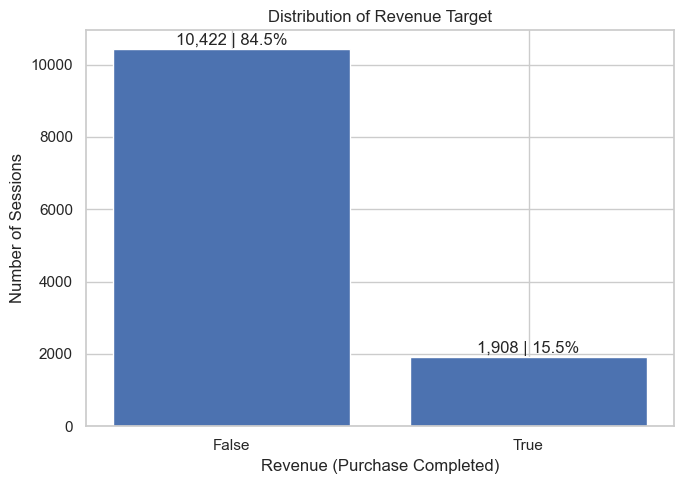

Non-purchase to purchase ratio: 5.46:1
Interpretation: accuracy alone may reward a model that predicts mostly non-purchases.


In [6]:
# Visualise target counts and percentages to make class imbalance explicit.
fig, ax = plt.subplots(figsize=(7, 5))
target_plot_counts = df['Revenue'].value_counts().sort_index()
ax.bar(target_plot_counts.index.astype(str), target_plot_counts.values)
ax.set_title('Distribution of Revenue Target')
ax.set_xlabel('Revenue (Purchase Completed)')
ax.set_ylabel('Number of Sessions')

counts = df['Revenue'].value_counts().sort_index()
for i, count in enumerate(counts):
    pct = count / len(df) * 100
    ax.text(i, count + len(df) * 0.01, f'{count:,} | {pct:.1f}%', ha='center')
plt.tight_layout()
plt.show()

imbalance_ratio = counts.loc[False] / counts.loc[True]
print(f'Non-purchase to purchase ratio: {imbalance_ratio:.2f}:1')
print('Interpretation: accuracy alone may reward a model that predicts mostly non-purchases.')

### 2.3.1.2 Understanding distribution of features

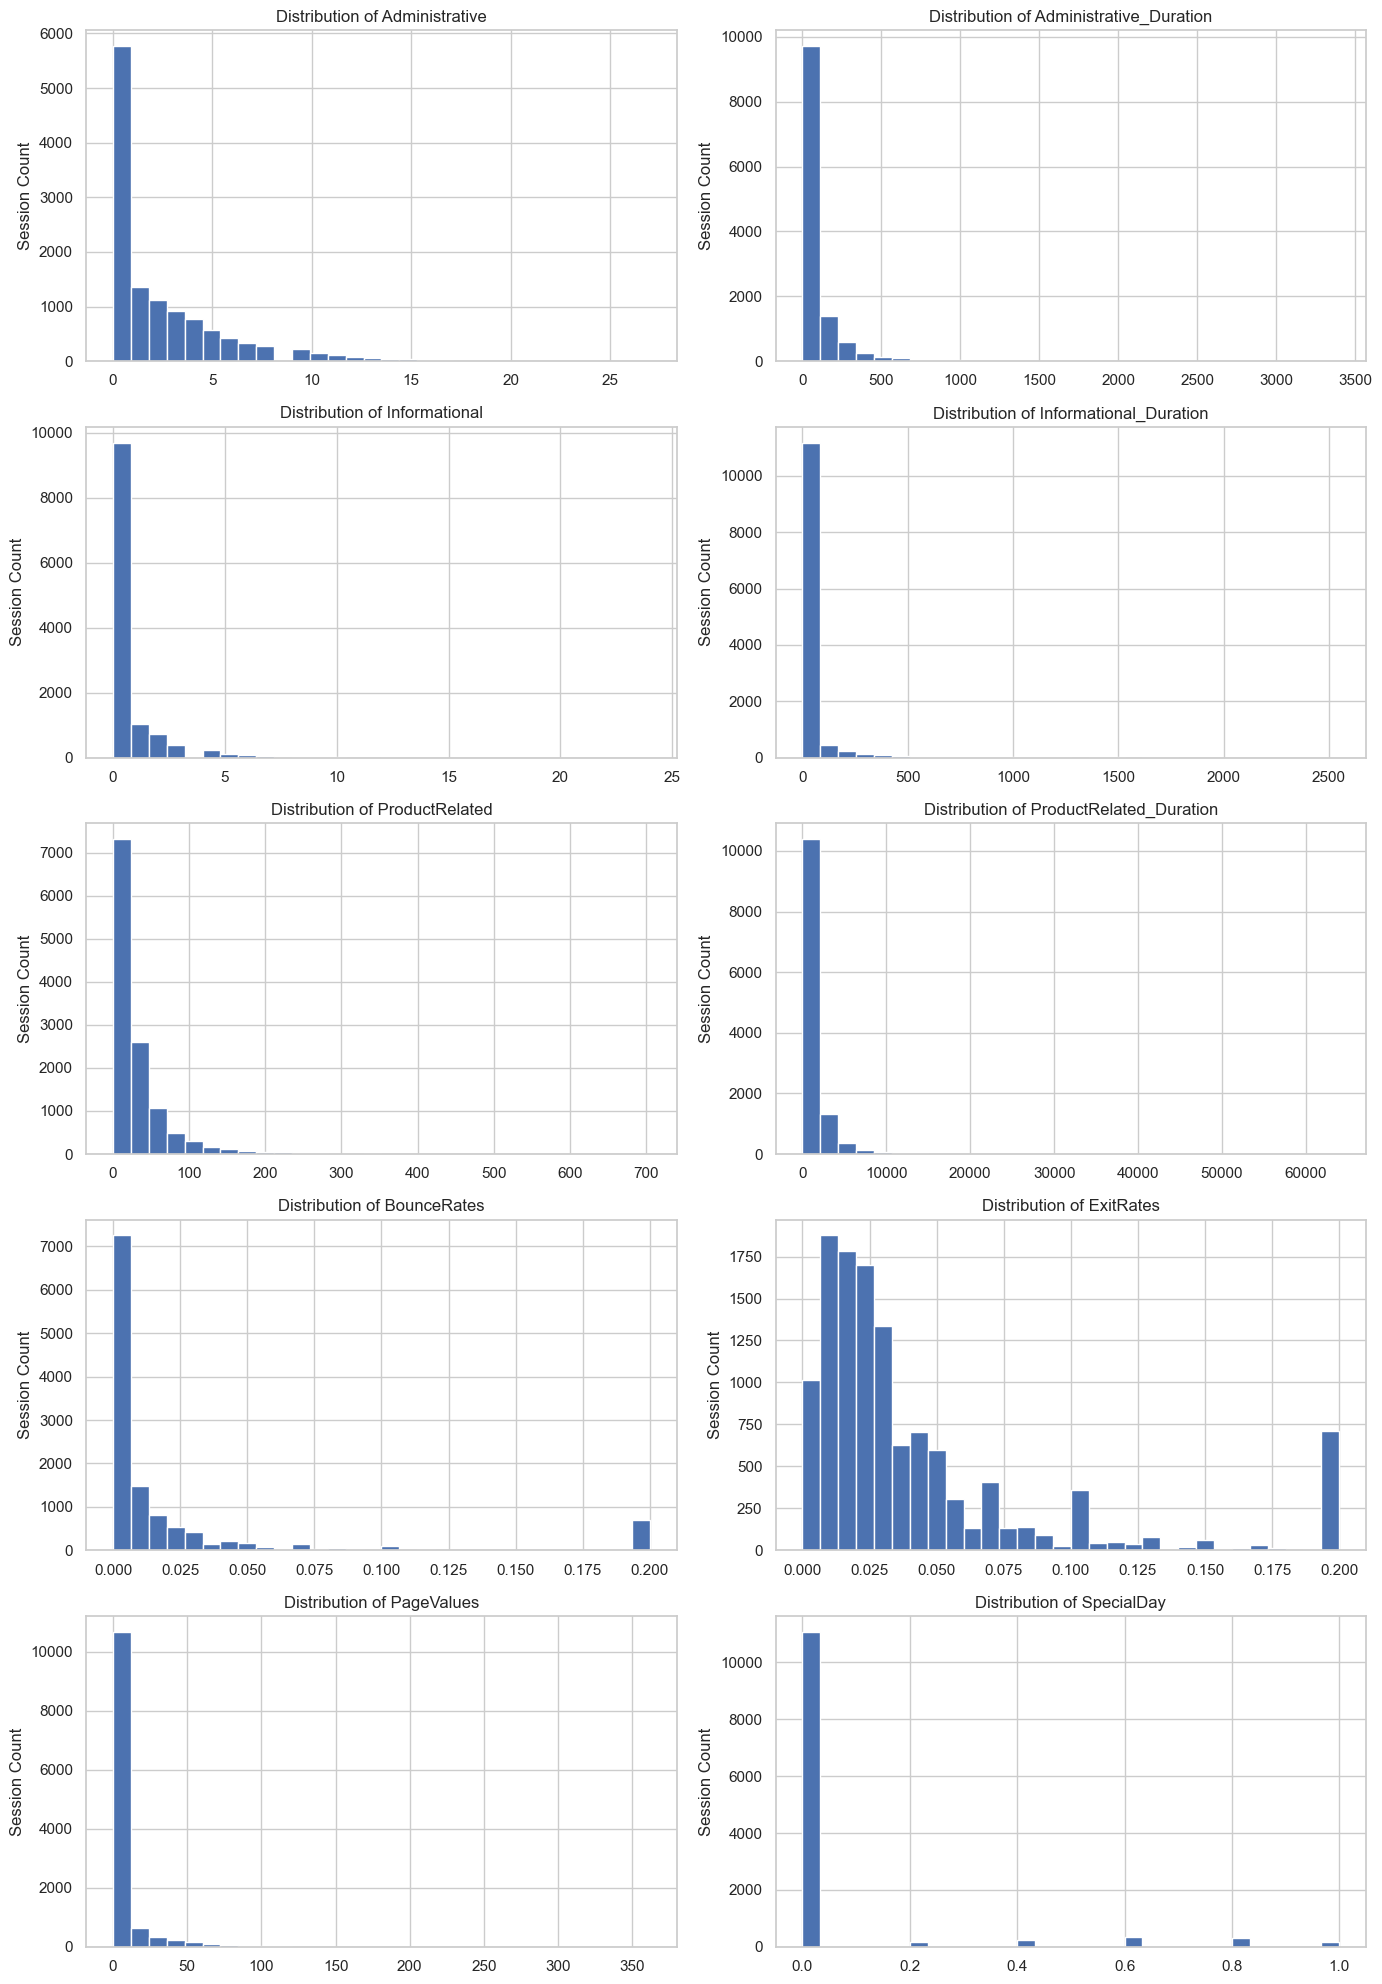

Skewness of numeric features (absolute values above 1 indicate strong skew):


,Skewness
Informational_Duration,7.579185
ProductRelated_Duration,7.263228
PageValues,6.382964
Administrative_Duration,5.615719
ProductRelated,4.341516
Informational,4.036464
SpecialDay,3.302667
BounceRates,2.947855
ExitRates,2.148789
Administrative,1.960357


In [7]:
# Plot key numeric distributions. Log-scaled y-axes make low-frequency tails easier to see.
key_numeric = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()
for ax, col in zip(axes, key_numeric):
    ax.hist(df[col].dropna(), bins=30)
    ax.set_title(f'Distribution of {col}')
    ax.set_ylabel('Session Count')
plt.tight_layout()
plt.show()

print('Skewness of numeric features (absolute values above 1 indicate strong skew):')
display(df[key_numeric].skew().sort_values(ascending=False).to_frame('Skewness'))

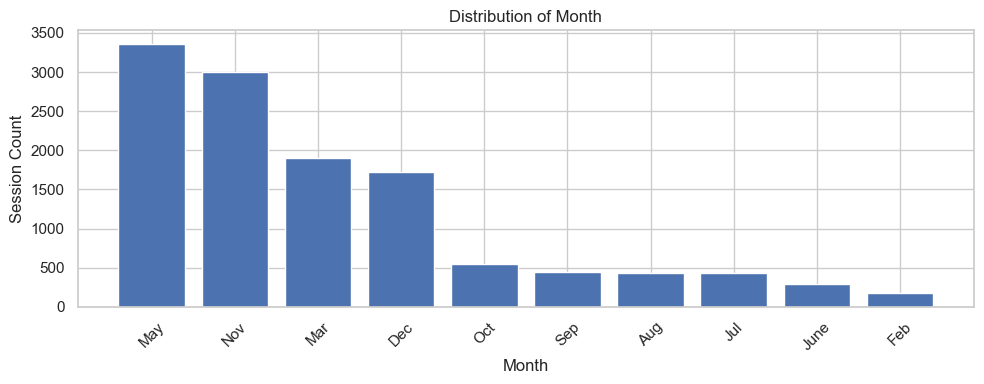

Month value counts:


,Count
Month,
May,3364
Nov,2998
Mar,1907
Dec,1727
Oct,549
Sep,448
Aug,433
Jul,432
June,288


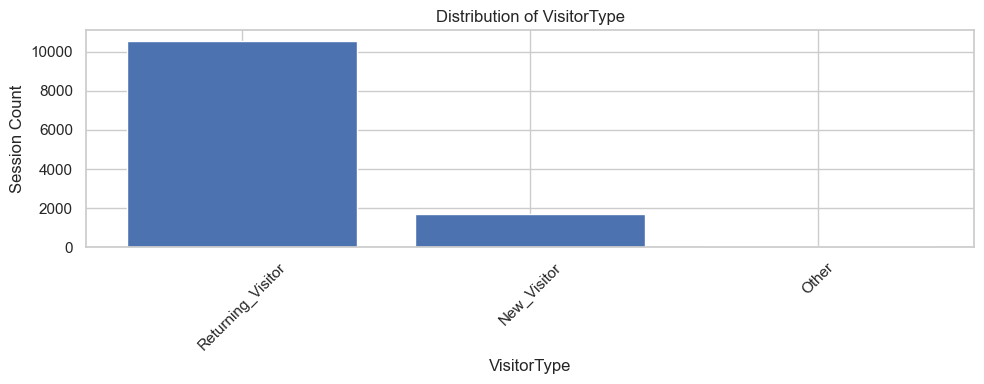

VisitorType value counts:


,Count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


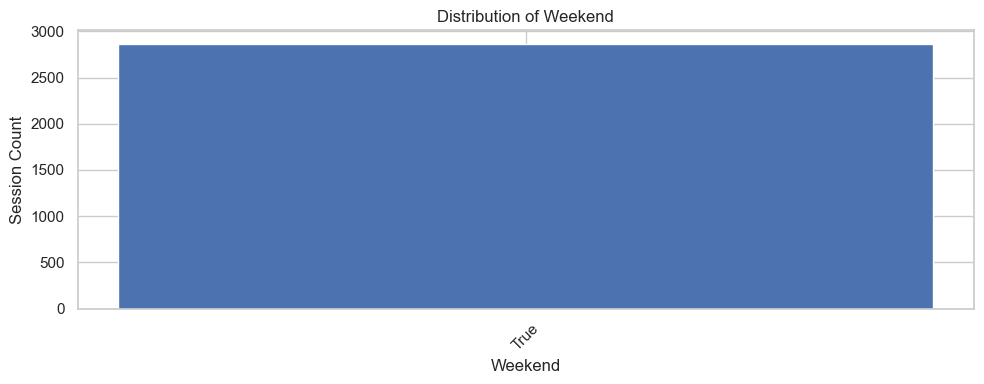

Weekend value counts:


,Count
Weekend,
False,9462
True,2868


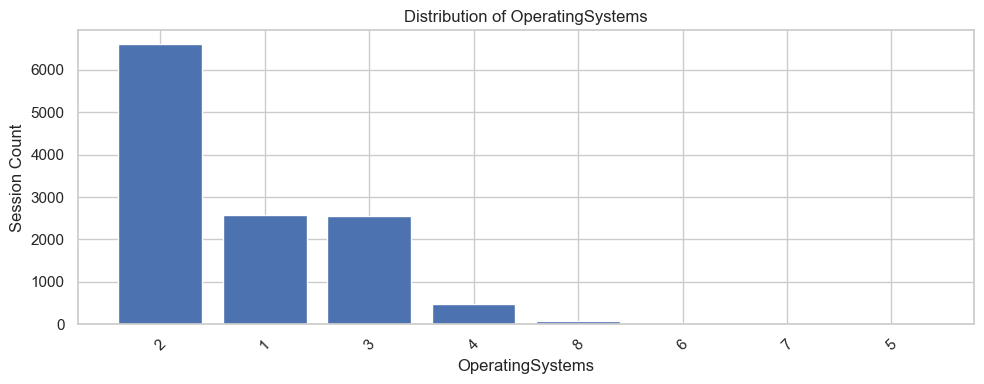

OperatingSystems value counts:


,Count
OperatingSystems,
2,6601
1,2585
3,2555
4,478
8,79
6,19
7,7
5,6


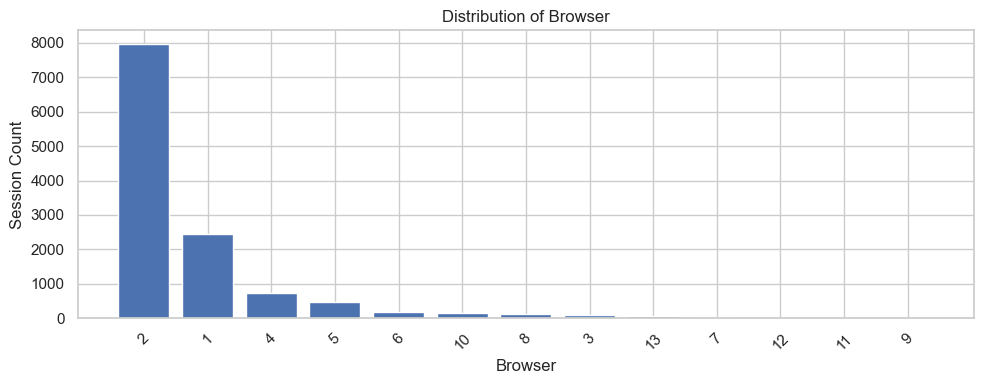

Browser value counts:


,Count
Browser,
2,7961
1,2462
4,736
5,467
6,174
10,163
8,135
3,105
13,61


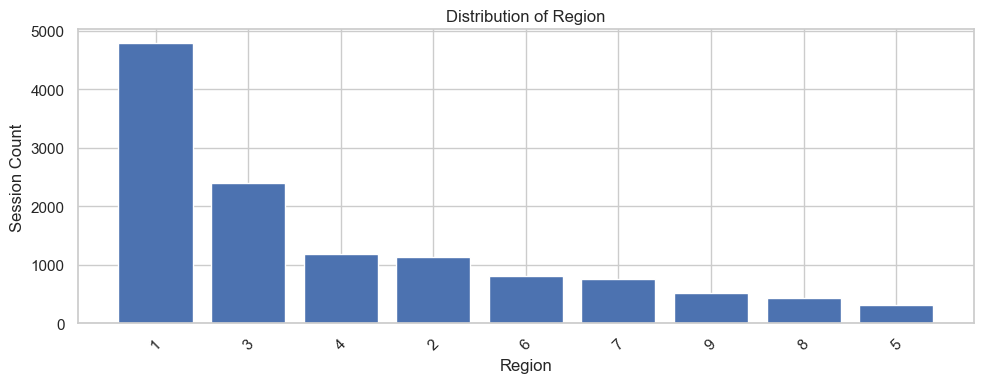

Region value counts:


,Count
Region,
1,4780
3,2403
4,1182
2,1136
6,805
7,761
9,511
8,434
5,318


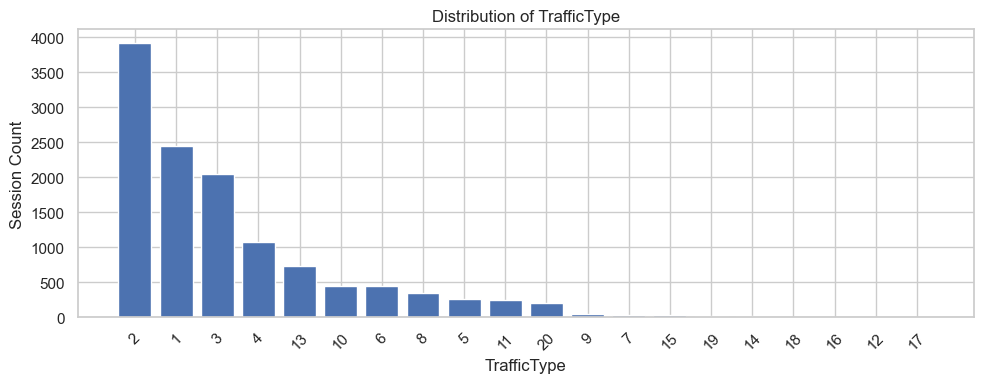

TrafficType value counts:


,Count
TrafficType,
2,3913
1,2451
3,2052
4,1069
13,738
10,450
6,444
8,343
5,260


In [8]:
# Plot categorical feature distributions.
categorical_for_plot = ['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

for col in categorical_for_plot:
    plt.figure(figsize=(10, 4))
    order = df[col].value_counts().index
    category_counts = df[col].value_counts().loc[order]
    plt.bar(category_counts.index.astype(str), category_counts.values)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Session Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(f'{col} value counts:')
    display(df[col].value_counts().to_frame('Count').head(20))

**Feature-distribution interpretation**

The activity-count, duration and `PageValues` variables are right-skewed. This suggests that scaling is important for Logistic Regression and that tree-based models may capture non-linear behaviour without requiring a normal distribution. Categorical values are unevenly represented, so one-hot encoding is used rather than treating category codes as ordered numbers. Extreme values are retained because long, highly engaged sessions may be genuine high-intent behaviour rather than data errors; tree models are robust to such values, while the Logistic Regression pipeline uses standardisation.

### 2.3.2 Understanding relationship between variables

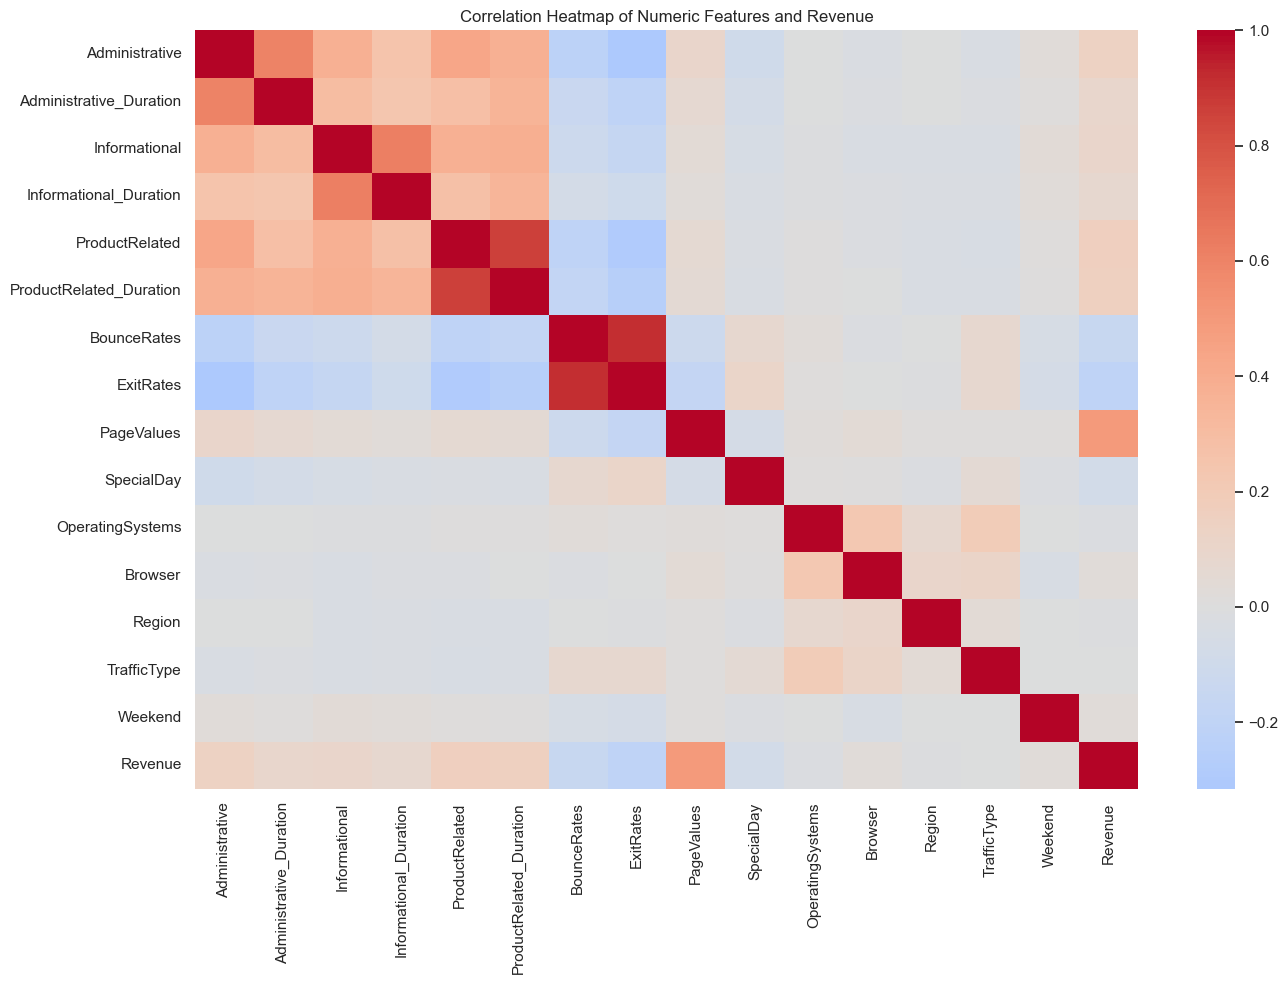

Numeric correlations with Revenue (sorted by absolute strength):


,Correlation_with_Revenue
PageValues,0.492569
ExitRates,-0.207071
ProductRelated,0.158538
ProductRelated_Duration,0.152373
BounceRates,-0.150673
Administrative,0.138917
Informational,0.095200
Administrative_Duration,0.093587
SpecialDay,-0.082305
Informational_Duration,0.070345


In [9]:
# Correlation heatmap for numeric variables, including the boolean target converted to 0/1.
numeric_for_corr = df.select_dtypes(include=[np.number, 'bool']).copy()
numeric_for_corr['Revenue'] = numeric_for_corr['Revenue'].astype(int)

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_for_corr.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Numeric Features and Revenue')
plt.tight_layout()
plt.show()

revenue_corr = numeric_for_corr.corr()['Revenue'].drop('Revenue').sort_values(key=abs, ascending=False)
print('Numeric correlations with Revenue (sorted by absolute strength):')
display(revenue_corr.to_frame('Correlation_with_Revenue'))

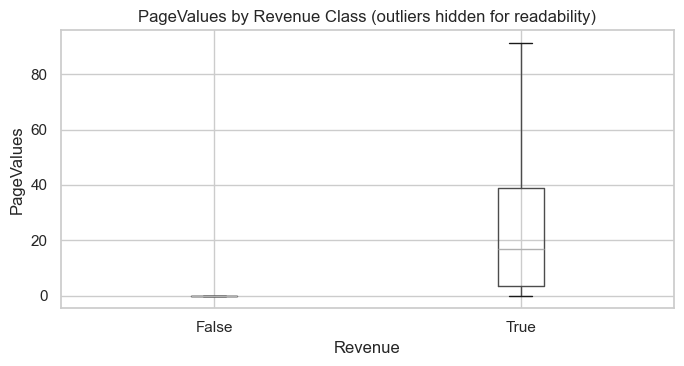

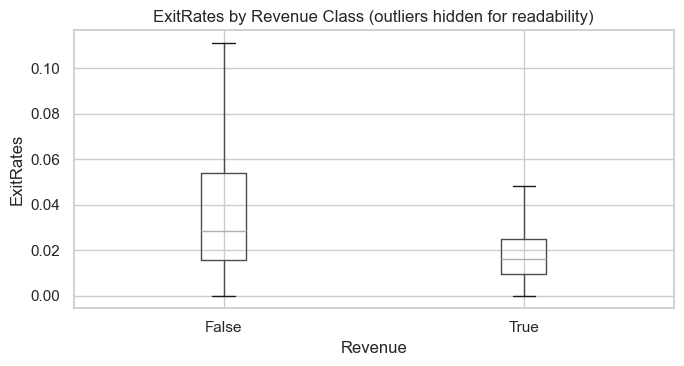

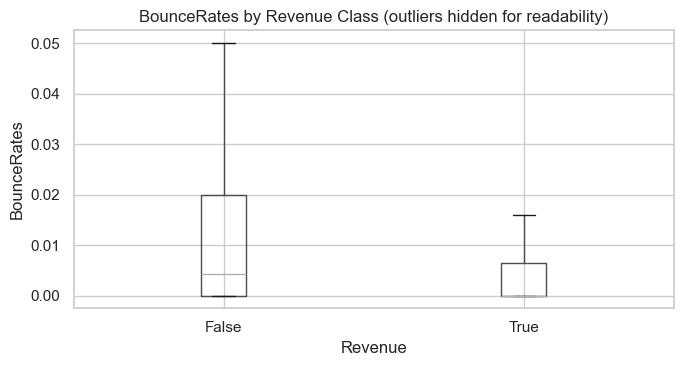

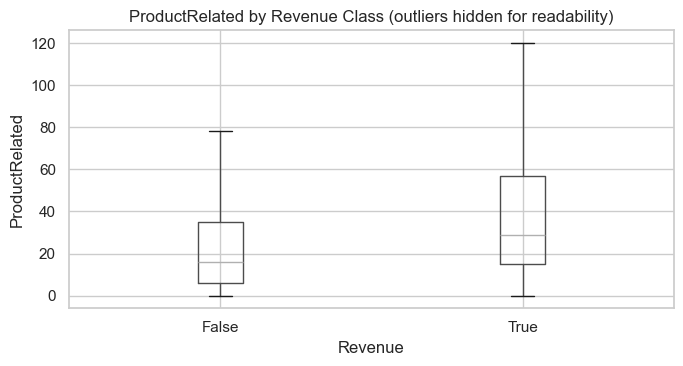

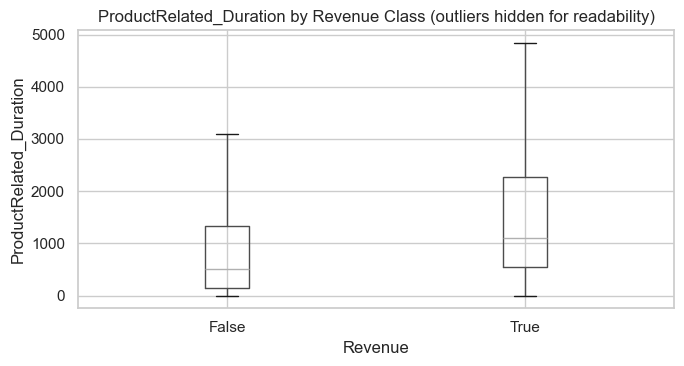

Median values by target class:


Revenue,False,True
PageValues,0.000000,16.758134
ExitRates,0.028571,0.016000
BounceRates,0.004255,0.000000
ProductRelated,16.000000,29.000000
ProductRelated_Duration,510.190000,1109.906250


In [10]:
# Compare important numeric features by target class.
relationship_features = ['PageValues', 'ExitRates', 'BounceRates', 'ProductRelated', 'ProductRelated_Duration']

for col in relationship_features:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=col, by='Revenue', showfliers=False, ax=plt.gca())
    plt.suptitle('')
    plt.title(f'{col} by Revenue Class (outliers hidden for readability)')
    plt.xlabel('Revenue')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

print('Median values by target class:')
display(df.groupby('Revenue')[relationship_features].median().T)

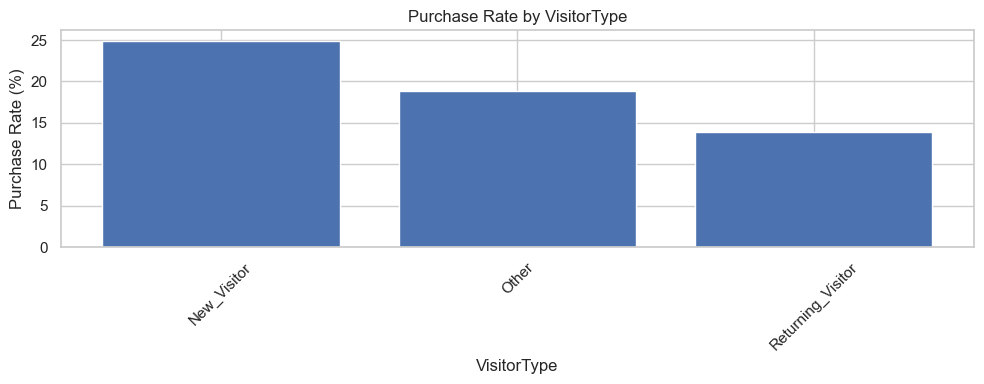

Purchase rate by VisitorType:


,Purchase_Rate_Percent
VisitorType,
New_Visitor,24.91
Other,18.82
Returning_Visitor,13.93


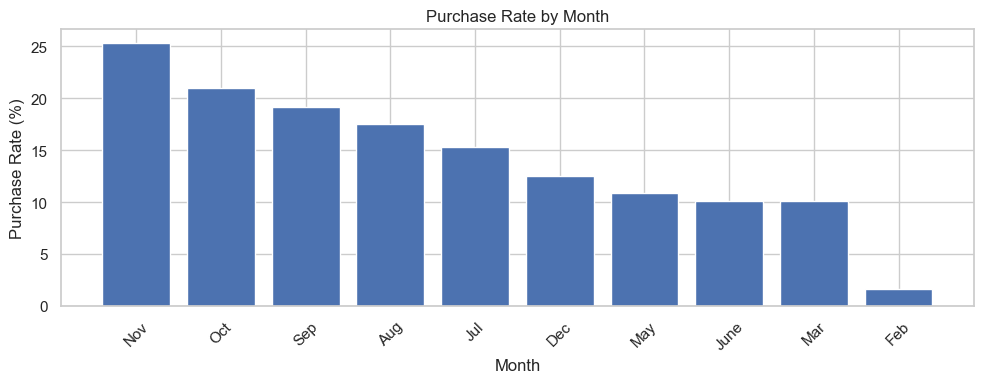

Purchase rate by Month:


,Purchase_Rate_Percent
Month,
Nov,25.35
Oct,20.95
Sep,19.20
Aug,17.55
Jul,15.28
Dec,12.51
May,10.85
June,10.07
Mar,10.07


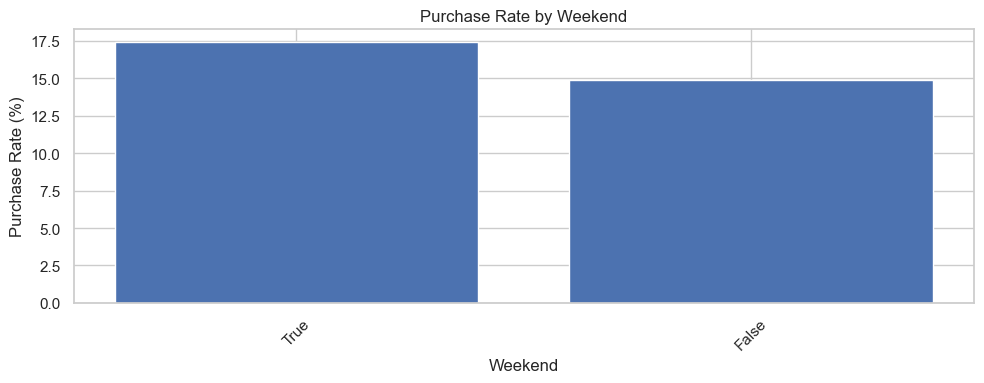

Purchase rate by Weekend:


,Purchase_Rate_Percent
Weekend,
True,17.40
False,14.89


In [11]:
# Purchase rate for selected categorical variables.
for col in ['VisitorType', 'Month', 'Weekend']:
    purchase_rate = (
        df.groupby(col, observed=False)['Revenue']
          .mean()
          .mul(100)
          .sort_values(ascending=False)
    )
    plt.figure(figsize=(10, 4))
    plt.bar(purchase_rate.index.astype(str), purchase_rate.values)
    plt.title(f'Purchase Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Purchase Rate (%)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print(f'Purchase rate by {col}:')
    display(purchase_rate.round(2).to_frame('Purchase_Rate_Percent'))

**Relationship interpretation and modelling implications**

`PageValues` has the clearest positive relationship with purchase completion, while `ExitRates` and `BounceRates` tend to be negatively related to purchasing. Purchasing sessions also tend to show greater product engagement. These patterns support creating engagement-based aggregate features during iterative development. Correlation does not prove causation, and a low linear correlation does not mean a feature is useless because tree models can learn non-linear relationships and interactions.

# 3. Data Preparation

## 3.1 Data Cleaning

In [12]:
# Work on a copy so that the original loaded data remains available for reference.
data = df.copy()

# Remove exact duplicate sessions. This prevents duplicated observations from receiving extra weight.
rows_before = len(data)
data = data.drop_duplicates().reset_index(drop=True)
rows_after = len(data)
print(f'Duplicate rows removed: {rows_before - rows_after}')
print(f'Cleaned dataset shape: {data.shape}')

# Convert the boolean target to integer labels for consistent metric reporting.
data['Revenue'] = data['Revenue'].astype(int)

# Explicitly define feature roles.
target_column = 'Revenue'
categorical_features = [
    'Month', 'OperatingSystems', 'Browser', 'Region',
    'TrafficType', 'VisitorType', 'Weekend'
]
numeric_features = [col for col in data.columns if col not in categorical_features + [target_column]]

print()
print('Numeric features:')
print(numeric_features)
print()
print('Categorical features:')
print(categorical_features)
print()
print('Target classes after conversion:')
print(data[target_column].value_counts().sort_index())

Duplicate rows removed: 125
Cleaned dataset shape: (12205, 18)

Numeric features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Categorical features:
['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

Target classes after conversion:
Revenue
0    10297
1     1908
Name: count, dtype: int64


**Cleaning and preprocessing rationale**

- Exact duplicate rows are removed because repeated identical sessions could over-weight a pattern and create an overly optimistic evaluation if copies appear in both train and test sets.
- No missing values are currently present, but imputers remain inside the preprocessing pipelines. This makes the workflow robust and ensures the same process can handle a future session with a missing field.
- Numeric features use median imputation. The median is less affected by skew and extreme values than the mean.
- Categorical features use most-frequent imputation and one-hot encoding. One-hot encoding avoids falsely implying that codes such as Browser 2 are numerically greater than Browser 1.
- Numeric features are standardised for Logistic Regression because its optimisation and coefficients are scale-sensitive. Random Forest does not need scaling, but a shared preprocessing pipeline is retained for a fair and reproducible workflow.
- Outliers are not deleted automatically. Long or high-value sessions may be valid business signals, and deleting them could remove genuine purchasers.

## 3.2 Train-Test Split

In [13]:
# Separate predictors and target.
X = data.drop(columns=target_column)
y = data[target_column]

# Use a stratified 80/20 split so both sets retain approximately the same purchase rate.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print()
print('Class proportions:')
split_balance = pd.DataFrame({
    'Full_Data': y.value_counts(normalize=True).sort_index(),
    'Training_Set': y_train.value_counts(normalize=True).sort_index(),
    'Test_Set': y_test.value_counts(normalize=True).sort_index()
}).mul(100).round(2)
display(split_balance)

print('Justification: 20% provides a sufficiently large unseen test set while retaining 80% for training. Stratification preserves the minority purchase class.')

Training shape: (9764, 17)
Test shape: (2441, 17)

Class proportions:


,Full_Data,Training_Set,Test_Set
Revenue,,,
0,84.37,84.37,84.35
1,15.63,15.63,15.65


Justification: 20% provides a sufficiently large unseen test set while retaining 80% for training. Stratification preserves the minority purchase class.


# 4. Modelling

The first modelling round compares three approaches:

1. **DummyClassifier (majority-class baseline):** establishes how a model performs without learning useful relationships.
2. **Logistic Regression:** an interpretable linear classifier and a strong baseline after one-hot encoding and scaling. `class_weight='balanced'` gives more influence to the minority purchase class.
3. **Random Forest:** a non-linear ensemble that can model interactions and threshold effects. `class_weight='balanced'` addresses target imbalance without generating synthetic records.

No synthetic oversampling is used because the specification prohibits synthetically generated data and the project can address imbalance through class weighting, stratification and suitable metrics.

### 4.2 Train Model

In [14]:
# Build reusable preprocessing objects.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

models = {
    'Majority Baseline': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
    ]),
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ])
}

trained_models = {}
for name, model in models.items():
    print('=' * 75)
    print(f'Training: {name}')
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f'Completed: {name}')

print()
print('All initial models trained successfully.')

Training: Majority Baseline
Completed: Majority Baseline
Training: Logistic Regression
Completed: Logistic Regression
Training: Random Forest
Completed: Random Forest

All initial models trained successfully.


# 5. Model Evaluation

In [15]:
# Evaluation helper to calculate the same metrics for every classifier.
def evaluate_classifier(name, model, X_eval, y_eval):
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_eval, predictions),
        'Precision': precision_score(y_eval, predictions, zero_division=0),
        'Recall': recall_score(y_eval, predictions, zero_division=0),
        'F1': f1_score(y_eval, predictions, zero_division=0),
        'ROC_AUC': roc_auc_score(y_eval, probabilities),
        'PR_AUC': average_precision_score(y_eval, probabilities)
    }

    print('=' * 75)
    print(name)
    print('-' * 75)
    print(classification_report(y_eval, predictions, target_names=['No Purchase', 'Purchase'], zero_division=0))
    print('Confusion matrix:')
    print(confusion_matrix(y_eval, predictions))
    return metrics, predictions, probabilities

initial_results = []
initial_predictions = {}
initial_probabilities = {}

for name, model in trained_models.items():
    metrics, preds, probs = evaluate_classifier(name, model, X_test, y_test)
    initial_results.append(metrics)
    initial_predictions[name] = preds
    initial_probabilities[name] = probs

results_df = pd.DataFrame(initial_results).set_index('Model').sort_values('F1', ascending=False)
print()
print('INITIAL TEST-SET COMPARISON')
display(results_df.round(4))

Majority Baseline
---------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.84      1.00      0.92      2059
    Purchase       0.00      0.00      0.00       382

    accuracy                           0.84      2441
   macro avg       0.42      0.50      0.46      2441
weighted avg       0.71      0.84      0.77      2441

Confusion matrix:
[[2059    0]
 [ 382    0]]
Logistic Regression
---------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.96      0.86      0.90      2059
    Purchase       0.50      0.80      0.62       382

    accuracy                           0.85      2441
   macro avg       0.73      0.83      0.76      2441
weighted avg       0.89      0.85      0.86      2441

Confusion matrix:
[[1761  298]
 [  78  304]]
Random Forest
----------------------------------------------------

,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
Logistic Regression,0.8460,0.5050,0.7958,0.6179,0.9097,0.6627
Random Forest,0.8955,0.7414,0.5105,0.6047,0.9234,0.7305
Majority Baseline,0.8435,0.0000,0.0000,0.0000,0.5000,0.1565


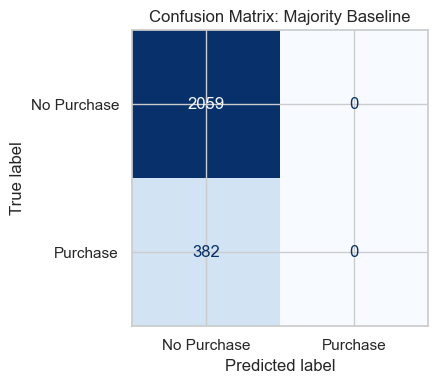

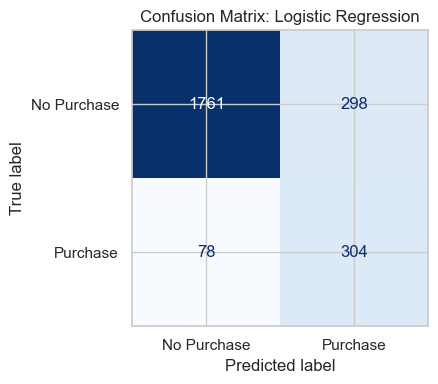

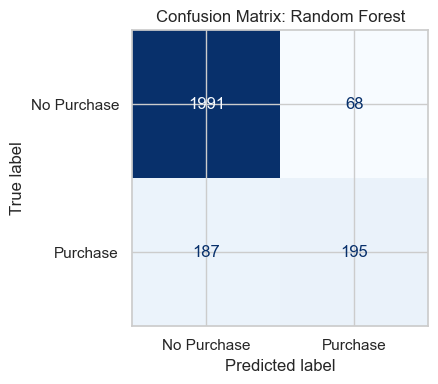

In [16]:
# Plot confusion matrices for direct error comparison.
for name, preds in initial_predictions.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=['No Purchase', 'Purchase'],
        cmap='Blues',
        ax=ax,
        colorbar=False
    )
    ax.set_title(f'Confusion Matrix: {name}')
    plt.tight_layout()
    plt.show()

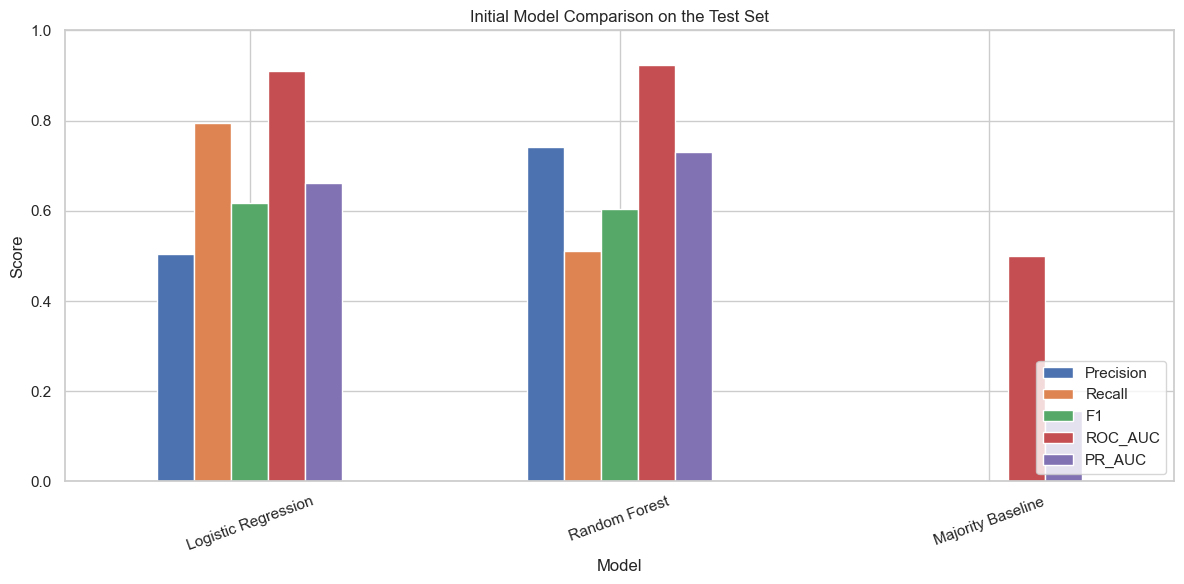

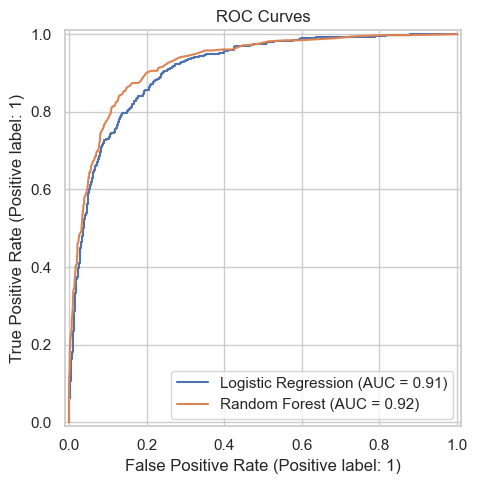

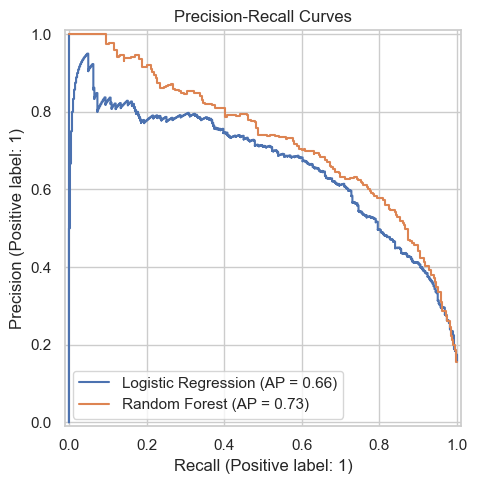

In [17]:
# Compare model metrics visually.
plot_metrics = ['Precision', 'Recall', 'F1', 'ROC_AUC', 'PR_AUC']
results_df[plot_metrics].plot(kind='bar', figsize=(12, 6))
plt.title('Initial Model Comparison on the Test Set')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ROC and Precision-Recall curves for learned models.
fig, ax = plt.subplots(figsize=(7, 5))
for name in ['Logistic Regression', 'Random Forest']:
    RocCurveDisplay.from_predictions(y_test, initial_probabilities[name], name=name, ax=ax)
ax.set_title('ROC Curves')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for name in ['Logistic Regression', 'Random Forest']:
    PrecisionRecallDisplay.from_predictions(y_test, initial_probabilities[name], name=name, ax=ax)
ax.set_title('Precision-Recall Curves')
plt.tight_layout()
plt.show()

**Initial evaluation interpretation**

The majority baseline is expected to achieve high raw accuracy because most sessions are non-purchases, but it has zero recall and zero F1 for purchasers. This demonstrates why accuracy is not an acceptable primary metric. The learned models are judged mainly by purchase-class F1, with recall, precision and PR-AUC used to understand the business trade-off. The strongest initial model becomes the candidate for feature engineering and tuning.

In [18]:
# Demonstrate end-to-end predictions on unseen rows from the held-out test set.
best_initial_name = results_df.index[0]
best_initial_model = trained_models[best_initial_name]

sample_new_sessions = X_test.sample(5, random_state=7).copy()
sample_actual = y_test.loc[sample_new_sessions.index]
sample_pred = best_initial_model.predict(sample_new_sessions)
sample_prob = best_initial_model.predict_proba(sample_new_sessions)[:, 1]

sample_output = sample_new_sessions[['PageValues', 'ExitRates', 'BounceRates', 'VisitorType', 'Month', 'Weekend']].copy()
sample_output['Predicted_Purchase'] = sample_pred.astype(bool)
sample_output['Purchase_Probability'] = sample_prob.round(4)
sample_output['Actual_Revenue'] = sample_actual.astype(bool)

print('Best initial model used for demonstration:', best_initial_name)
print('Five unseen test sessions and their predictions:')
display(sample_output)

Best initial model used for demonstration: Logistic Regression
Five unseen test sessions and their predictions:


,PageValues,ExitRates,BounceRates,VisitorType,Month,Weekend,Predicted_Purchase,Purchase_Probability,Actual_Revenue
10015,14.624136,0.023796,0.007179,Returning_Visitor,Nov,True,True,0.9117,False
10676,10.098678,0.006410,0.000000,Returning_Visitor,Nov,False,True,0.8056,True
10782,0.000000,0.000505,0.000000,Returning_Visitor,Dec,True,False,0.2227,False
2837,0.000000,0.015385,0.004808,Returning_Visitor,May,False,False,0.3992,False
8249,5.482896,0.020956,0.004374,Returning_Visitor,Nov,False,True,0.7787,True


## Iterative model development

### Feature engineering experiment

EDA showed that purchasing is related not only to individual page variables but also to overall session engagement. Four deterministic features are created:

- `TotalPages`: total number of administrative, informational and product-related pages.
- `TotalDuration`: total time spent across the three page groups.
- `ProductDurationPerPage`: average product-related duration per product page, using a small denominator safeguard.
- `ExitBounceGap`: difference between exit rate and bounce rate, capturing whether users tend to continue beyond the entry page before leaving.

These features combine related signals and may make interactions easier for a model to learn. They do not use target information, so they do not introduce target leakage. The engineered Random Forest is compared against the original Random Forest on the same held-out test set.

In [19]:
# Create deterministic engagement features for train and test data.
def add_engineered_features(frame):
    engineered = frame.copy()
    engineered['TotalPages'] = (
        engineered['Administrative'] +
        engineered['Informational'] +
        engineered['ProductRelated']
    )
    engineered['TotalDuration'] = (
        engineered['Administrative_Duration'] +
        engineered['Informational_Duration'] +
        engineered['ProductRelated_Duration']
    )
    engineered['ProductDurationPerPage'] = (
        engineered['ProductRelated_Duration'] /
        (engineered['ProductRelated'] + 1)
    )
    engineered['ExitBounceGap'] = engineered['ExitRates'] - engineered['BounceRates']
    return engineered

X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

engineered_numeric_features = numeric_features + [
    'TotalPages', 'TotalDuration', 'ProductDurationPerPage', 'ExitBounceGap'
]

print('Original feature count:', X_train.shape[1])
print('Engineered feature count:', X_train_fe.shape[1])
print('New features:', [c for c in X_train_fe.columns if c not in X_train.columns])
display(X_train_fe[['TotalPages', 'TotalDuration', 'ProductDurationPerPage', 'ExitBounceGap']].head())

Original feature count: 17
Engineered feature count: 21
New features: ['TotalPages', 'TotalDuration', 'ProductDurationPerPage', 'ExitBounceGap']


,TotalPages,TotalDuration,ProductDurationPerPage,ExitBounceGap
7469,51,1256.000000,24.474419,0.004545
11804,30,901.288889,29.073835,0.007333
3250,13,421.166667,30.083333,0.028205
204,7,598.500000,93.083333,0.028571
4392,16,1599.266667,94.074510,0.013333


In [20]:
# Build and evaluate an untuned Random Forest using engineered features.
engineered_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), engineered_numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

rf_engineered = Pipeline(steps=[
    ('preprocessor', engineered_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

print('Training engineered-feature Random Forest...')
rf_engineered.fit(X_train_fe, y_train)
print('Training completed.')

fe_metrics, fe_preds, fe_probs = evaluate_classifier(
    'Random Forest + Engineered Features', rf_engineered, X_test_fe, y_test
)

before_after_fe = pd.DataFrame([
    {**results_df.loc['Random Forest'].to_dict(), 'Model': 'Original Random Forest'},
    fe_metrics
]).set_index('Model')
print('FEATURE ENGINEERING: BEFORE VS AFTER')
display(before_after_fe.round(4))

Training engineered-feature Random Forest...
Training completed.
Random Forest + Engineered Features
---------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.91      0.97      0.94      2059
    Purchase       0.77      0.51      0.61       382

    accuracy                           0.90      2441
   macro avg       0.84      0.74      0.78      2441
weighted avg       0.89      0.90      0.89      2441

Confusion matrix:
[[2002   57]
 [ 189  193]]
FEATURE ENGINEERING: BEFORE VS AFTER


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
Original Random Forest,0.8955,0.7414,0.5105,0.6047,0.9234,0.7305
Random Forest + Engineered Features,0.8992,0.7720,0.5052,0.6108,0.9204,0.7259


### Hyperparameter tuning with RandomizedSearchCV

The engineered Random Forest is tuned because it can model the non-linear patterns observed in EDA. Exactly two hyperparameters are varied, and each has no more than three candidate values:

- `n_estimators`: `[50, 100, 150]`
- `max_depth`: `[None, 10, 20]`

The search uses stratified cross-validation internally and optimises **F1 for the positive purchase class**. `random_state=42` makes the process reproducible. Verbose output is enabled so the training logs are visible.

In [21]:
# RandomizedSearchCV: only two hyperparameters, with three values each.
param_distributions = {
    'model__n_estimators': [50, 100, 150],
    'model__max_depth': [None, 10, 20]
}

rf_for_tuning = Pipeline(steps=[
    ('preprocessor', engineered_preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1
    ))
])

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=param_distributions,
    n_iter=4,
    scoring='f1',
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2,
    return_train_score=True
)

print('Starting RandomizedSearchCV...')
print('Candidate values:', param_distributions)
random_search.fit(X_train_fe, y_train)
print()
print('RandomizedSearchCV completed.')
print('Best parameters:', random_search.best_params_)
print('Best mean cross-validation F1:', round(random_search.best_score_, 4))

Starting RandomizedSearchCV...
Candidate values: {'model__n_estimators': [50, 100, 150], 'model__max_depth': [None, 10, 20]}
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .......model__max_depth=20, model__n_estimators=100; total time=   0.7s
[CV] END .......model__max_depth=20, model__n_estimators=100; total time=   0.7s
[CV] END .......model__max_depth=20, model__n_estimators=100; total time=   0.7s
[CV] END .....model__max_depth=None, model__n_estimators=100; total time=   0.7s
[CV] END .....model__max_depth=None, model__n_estimators=100; total time=   0.7s
[CV] END .....model__max_depth=None, model__n_estimators=100; total time=   0.7s
[CV] END .......model__max_depth=10, model__n_estimators=150; total time=   0.8s
[CV] END .......model__max_depth=10, model__n_estimators=150; total time=   0.8s
[CV] END .......model__max_depth=10, model__n_estimators=150; total time=   0.8s
[CV] END ......model__max_depth=None, model__n_estimators=50; total time=   0.3s
[CV] 

In [22]:
# Show detailed cross-validation logs as a table.
cv_results = pd.DataFrame(random_search.cv_results_)
cv_display = cv_results[[
    'rank_test_score', 'param_model__n_estimators', 'param_model__max_depth',
    'mean_train_score', 'std_train_score', 'mean_test_score', 'std_test_score',
    'mean_fit_time'
]].sort_values('rank_test_score')

print('RANDOMIZED SEARCH COMPARISON TABLE')
display(cv_display.round(4))

RANDOMIZED SEARCH COMPARISON TABLE


,rank_test_score,param_model__n_estimators,param_model__max_depth,mean_train_score,std_train_score,mean_test_score,std_test_score,mean_fit_time
2,1,150,10,0.7690,0.0036,0.6646,0.0064,0.8596
0,2,100,20,0.9967,0.0013,0.6195,0.0077,0.7359
1,3,100,None,1.0000,0.0000,0.6026,0.0136,0.7277
3,4,50,None,0.9993,0.0002,0.5935,0.0113,0.3992


Tuned Random Forest + Engineered Features
---------------------------------------------------------------------------
              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92      2059
    Purchase       0.57      0.79      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.84      0.79      2441
weighted avg       0.90      0.88      0.88      2441

Confusion matrix:
[[1836  223]
 [  82  300]]
FINAL MODEL COMPARISON


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
Model,,,,,,
Tuned Random Forest + Engineered Features,0.8751,0.5736,0.7853,0.6630,0.9212,0.6975
Logistic Regression,0.8460,0.5050,0.7958,0.6179,0.9097,0.6627
Random Forest + Engineered Features,0.8992,0.7720,0.5052,0.6108,0.9204,0.7259
Original Random Forest,0.8955,0.7414,0.5105,0.6047,0.9234,0.7305
Majority Baseline,0.8435,0.0000,0.0000,0.0000,0.5000,0.1565


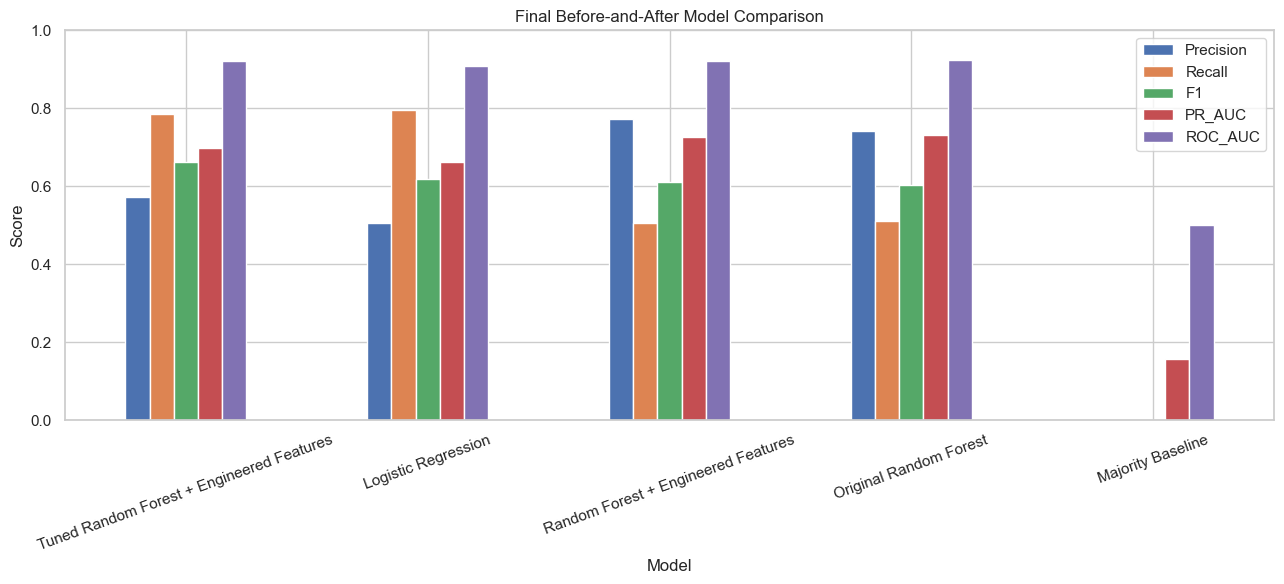

In [23]:
# Evaluate the tuned model on the untouched test set.
tuned_rf = random_search.best_estimator_
tuned_metrics, tuned_preds, tuned_probs = evaluate_classifier(
    'Tuned Random Forest + Engineered Features', tuned_rf, X_test_fe, y_test
)

final_comparison = pd.DataFrame([
    {**results_df.loc['Majority Baseline'].to_dict(), 'Model': 'Majority Baseline'},
    {**results_df.loc['Logistic Regression'].to_dict(), 'Model': 'Logistic Regression'},
    {**results_df.loc['Random Forest'].to_dict(), 'Model': 'Original Random Forest'},
    fe_metrics,
    tuned_metrics
]).set_index('Model').sort_values('F1', ascending=False)

print('FINAL MODEL COMPARISON')
display(final_comparison.round(4))

final_comparison[['Precision', 'Recall', 'F1', 'PR_AUC', 'ROC_AUC']].plot(
    kind='bar', figsize=(13, 6)
)
plt.title('Final Before-and-After Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

TOP 20 FEATURE IMPORTANCES FROM THE TUNED RANDOM FOREST


,Feature,Importance
8,num__PageValues,0.415753
7,num__ExitRates,0.069857
11,num__TotalDuration,0.051986
5,num__ProductRelated_Duration,0.051394
10,num__TotalPages,0.039628
6,num__BounceRates,0.035993
12,num__ProductDurationPerPage,0.035033
13,num__ExitBounceGap,0.034282
4,num__ProductRelated,0.031894
1,num__Administrative_Duration,0.028256


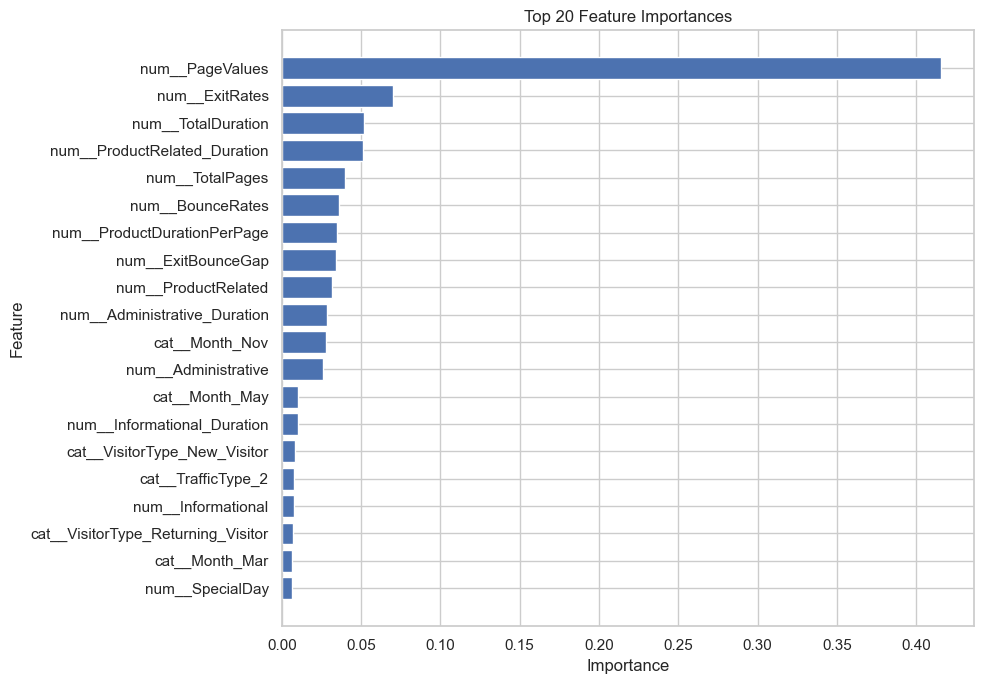

In [24]:
# Inspect the strongest transformed feature importances for business interpretation.
feature_names = tuned_rf.named_steps['preprocessor'].get_feature_names_out()
importances = tuned_rf.named_steps['model'].feature_importances_
feature_importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
      .sort_values('Importance', ascending=False)
      .head(20)
)

print('TOP 20 FEATURE IMPORTANCES FROM THE TUNED RANDOM FOREST')
display(feature_importance_df)

plt.figure(figsize=(10, 7))
plt.barh(feature_importance_df['Feature'][::-1], feature_importance_df['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

### Final model selection and business interpretation

The final model is selected using test-set evidence rather than accuracy alone. The preferred model should achieve the strongest purchase-class F1 while also maintaining useful recall, precision and PR-AUC. The comparison table above shows whether engineered features and tuning produced a genuine improvement over the original model and the majority baseline.

For SmartCart Insights, predicted probabilities can be converted into operational actions. A default threshold of 0.50 is demonstrated here. In deployment, the threshold should be reviewed with the business: a lower threshold would capture more potential purchasers but trigger more unnecessary interventions, while a higher threshold would reduce intervention volume but miss more purchasing sessions.

Feature importance is interpreted as predictive contribution, not causation. Variables such as `PageValues`, exit behaviour and product engagement can help rank intent, but the model does not prove that changing one feature will directly cause a purchase.

**Limitations and next steps:**
- Session behaviour and customer behaviour may change over time, so performance should be monitored after deployment.
- Probability calibration and threshold selection should be tested using real intervention costs and conversion outcomes.
- The model should be checked for data drift and retrained when feature distributions or purchase rates change.
- The present notebook uses only the provided dataset and does not claim causal impact.

In [25]:
# Final end-to-end demonstration using the selected tuned model.
final_sample = X_test_fe.sample(8, random_state=21).copy()
final_actual = y_test.loc[final_sample.index]
final_probability = tuned_rf.predict_proba(final_sample)[:, 1]
final_prediction = (final_probability >= 0.50).astype(int)

final_demo = final_sample[[
    'PageValues', 'ExitRates', 'BounceRates', 'ProductRelated',
    'ProductRelated_Duration', 'VisitorType', 'Month', 'Weekend',
    'TotalPages', 'TotalDuration'
]].copy()
final_demo['Predicted_Probability'] = final_probability.round(4)
final_demo['Predicted_Revenue'] = final_prediction.astype(bool)
final_demo['Actual_Revenue'] = final_actual.astype(bool)
final_demo['Suggested_Action'] = np.where(
    final_demo['Predicted_Revenue'],
    'High intent: consider timely intervention',
    'Lower intent: avoid costly intervention'
)

print('FINAL END-TO-END PREDICTION DEMONSTRATION')
display(final_demo)

print('Notebook workflow completed successfully.')

FINAL END-TO-END PREDICTION DEMONSTRATION


,PageValues,ExitRates,BounceRates,ProductRelated,ProductRelated_Duration,VisitorType,Month,Weekend,TotalPages,TotalDuration,Predicted_Probability,Predicted_Revenue,Actual_Revenue,Suggested_Action
299,0.000000,0.200000,0.200000,2,0.000000,Returning_Visitor,Mar,False,2,0.000000,0.0059,False,False,Lower intent: avoid costly intervention
388,0.000000,0.085714,0.057143,7,379.500000,Returning_Visitor,Mar,False,7,379.500000,0.0678,False,False,Lower intent: avoid costly intervention
11176,0.000000,0.200000,0.200000,1,0.000000,Returning_Visitor,Dec,False,1,0.000000,0.0101,False,False,Lower intent: avoid costly intervention
7268,0.000000,0.014286,0.000000,12,189.433333,New_Visitor,Sep,False,16,223.833333,0.2143,False,False,Lower intent: avoid costly intervention
1083,0.000000,0.133333,0.100000,1,67.000000,Returning_Visitor,Mar,False,1,67.000000,0.0153,False,False,Lower intent: avoid costly intervention
8695,8.403164,0.014594,0.004385,517,27009.859430,Returning_Visitor,Nov,False,540,28450.201097,0.6100,True,True,High intent: consider timely intervention
5278,0.000000,0.000833,0.000000,81,1421.668627,Returning_Visitor,May,False,83,1451.668627,0.2444,False,False,Lower intent: avoid costly intervention
3587,0.000000,0.010000,0.000000,8,261.600000,New_Visitor,May,False,11,382.266667,0.1775,False,False,Lower intent: avoid costly intervention


Notebook workflow completed successfully.


## Export Model for Deployment

Save the final tuned pipeline so it can be loaded by the Streamlit web application (`app.py`) without retraining.

In [26]:
# Export the final tuned pipeline (preprocessing + model) for deployment.
# The Streamlit app (app.py) loads this file directly and does not retrain anything.
import joblib

MODEL_EXPORT_PATH = 'smartcart_model.pkl'
joblib.dump(tuned_rf, MODEL_EXPORT_PATH)

print(f'Tuned Random Forest pipeline saved to: {MODEL_EXPORT_PATH}')


Tuned Random Forest pipeline saved to: smartcart_model.pkl
